### import libraries

In [6]:
import os
from collections import OrderedDict

import yaml
import numpy as np
import matplotlib.pyplot as plt

from XLO_sim import tools

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)


### Numerical-convergence transmittance sweeps

Plots T(ω) = I(ω)_last / I(ω)_0 (and dip metrics min(T), area, FWHM) for the
three grid-resolution sweeps produced by `scripts/generate_tgrid_sweep_configs.py`,
`generate_xygrid_sweep_configs.py`, and `generate_zgrid_sweep_configs.py` +
`scripts/run_convergence_sweep.py`. E_seed_uJ is fixed at 40 uJ throughout all
three sweeps; what varies is tgrid, xgrid=ygrid, or zgrid (one axis at a time,
the other two held at their sweep default -- see the generator scripts'
docstrings for exactly which values are held fixed in each case).

Each sweep's output lands in `data/convergence_<axis>_<SLURM_ARRAY_JOB_ID>/`,
with one `runs_tgridT_xgridX_ygridY_zgridZ/` folder per grid setting --
update the `data_path_*` variables below to point at your job IDs before
running.

In [30]:
def data_from_folder(folder_path, grid_key):
    """Average .npz outputs across repetitions, grouped by grid_key ('tgrid' or 'xgrid').

    Mirrors the E_seed-keyed data_from_folder() in plot-transmittance-vs-intensity.ipynb,
    but groups runs_.../ subfolders by a grid dimension (read back out of the
    copied-in YAML config) instead of E_seed_uJ, since E_seed_uJ is constant
    across a convergence sweep.
    """
    accumulated_arrays = {}
    aux_data = None

    for runs_folder in os.listdir(folder_path):
        runs_path = os.path.join(folder_path, runs_folder)
        if not os.path.isdir(runs_path):
            continue

        yaml_file = None
        for file_name in os.listdir(runs_path):
            if file_name.endswith('.yaml'):
                yaml_file = os.path.join(runs_path, file_name)
                break
        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue

        with open(yaml_file, 'r') as f:
            yaml_data = yaml.safe_load(f)

        grid_value = yaml_data[grid_key]
        E_seed_value = yaml_data['E_seed_uJ']
        aux_data = [
            E_seed_value,
            yaml_data['tgrid'], yaml_data['xgrid'], yaml_data['ygrid'], yaml_data['zgrid'],
            yaml_data['sigma1_Ka1_2p3'], yaml_data['sigma1_Ka1_other'], yaml_data['seed_duration_FWHM_t'],
        ]

        if grid_value not in accumulated_arrays:
            accumulated_arrays[grid_value] = {}

        npz_files = [f for f in os.listdir(runs_path) if f.endswith('.npz')]
        for file_name in npz_files:
            data = np.load(os.path.join(runs_path, file_name))
            for array_name in data.files:
                if array_name in accumulated_arrays[grid_value]:
                    accumulated_arrays[grid_value][array_name] += data[array_name]
                else:
                    accumulated_arrays[grid_value][array_name] = data[array_name]

        num_files = len(npz_files)
        for array_name in accumulated_arrays[grid_value]:
            accumulated_arrays[grid_value][array_name] /= num_files

    # Ascending grid value -- coarsest to finest, so convergence reads left-to-right.
    sorted_accumulated_arrays = OrderedDict(sorted(accumulated_arrays.items(), key=lambda x: x[0]))

    return sorted_accumulated_arrays, aux_data


def transmittance_dip_metrics(sorted_accumulated_arrays, w_mask=15, n_edge=10):
    """Return (grid_values, min_T, area_T, FWHM_T) across a converged sweep's T(ω) dip."""
    grid_values, min_T, area_T, FWHM_T = [], [], [], []

    for grid_value, arrays in sorted_accumulated_arrays.items():
        print(grid_value)
        womega_ar = arrays['womega_ar']
        I_int_thy_w_last = arrays['I_int_thy_w_last'] + 1e-5 * max(arrays['I_int_thy_w_last'])
        I_int_thy_w_0 = arrays['I_int_thy_w_0'] + 1e-5 * max(arrays['I_int_thy_w_0'])
        Tint_w = I_int_thy_w_last / I_int_thy_w_0

        mask = (womega_ar > -w_mask) & (womega_ar < w_mask)

        grid_values.append(grid_value)
        min_T.append(np.min(Tint_w[mask]))

        T_base = 0.5 * (np.mean(Tint_w[mask][:n_edge]) + np.mean(Tint_w[mask][-n_edge:]))
        dip = T_base - Tint_w[mask]
        area_T.append(np.trapz(dip))
        FWHM_T.append(tools.find_fwhm(womega_ar[mask], dip))

    return grid_values, min_T, area_T, FWHM_T


def plot_transmittance_sweep(sorted_accumulated_arrays, aux_data, grid_label, w_show=20):
    """T(ω) overlay (log-normed by grid value) + min/area/FWHM dip metrics vs grid value."""
    E_seed_value, tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t = aux_data

    grid_values = list(sorted_accumulated_arrays.keys())
    norm = plt.matplotlib.colors.LogNorm(vmin=min(grid_values), vmax=max(grid_values))
    cmap = plt.matplotlib.colormaps['viridis']

    str_pars_calc = (
        r'$E_{seed}$ = ' + f'{E_seed_value:.1f} uJ, ' +
        r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f} kbarn' +
        r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f} kbarn' +
        r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f} fs'
    )

    plt.figure()
    plt.title(f'transmittance vs {grid_label}\n' + str_pars_calc, fontsize=9)
    for grid_value, arrays in sorted_accumulated_arrays.items():
        print(grid_value)
        if grid_value > 15000:
            continue
        womega_ar = arrays['womega_ar']
        I_int_thy_w_last = arrays['I_int_thy_w_last'] + 1e-5 * max(arrays['I_int_thy_w_last'])
        I_int_thy_w_0 = arrays['I_int_thy_w_0'] + 1e-5 * max(arrays['I_int_thy_w_0'])
        Tint_w = I_int_thy_w_last / I_int_thy_w_0
        plt.plot(womega_ar, Tint_w, color=cmap(norm(grid_value)), label=f'{grid_label} = {grid_value}')

    plt.ylabel(r'$T(\omega)$')
    plt.xlabel(r'$\Delta\omega$ (eV)')
    plt.xlim(-w_show, w_show)
    plt.ylim(0.1, 0.5)
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.savefig(os.path.join(figs_path, f'convergence_{grid_label}_transmittance.pdf'))
    plt.show()

    grid_values, min_T, area_T, FWHM_T = transmittance_dip_metrics(sorted_accumulated_arrays)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    for ax, y, ylabel, title in zip(
        axs,
        [min_T, area_T, FWHM_T],
        ['min(T)', 'Area of transmittance dip', 'FWHM of transmittance dip (eV)'],
        ['Minimum transmittance', 'Dip area', 'Dip FWHM'],
    ):
        ax.plot(grid_values, y, marker='o')
        ax.set_xscale('log')
        ax.set_xlabel(grid_label)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} vs {grid_label}')
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(figs_path, f'convergence_{grid_label}_metrics.pdf'))
    plt.show()

    return grid_values, min_T, area_T, FWHM_T


### tgrid convergence

200
400
800
1600
3200
6400
12800
20000


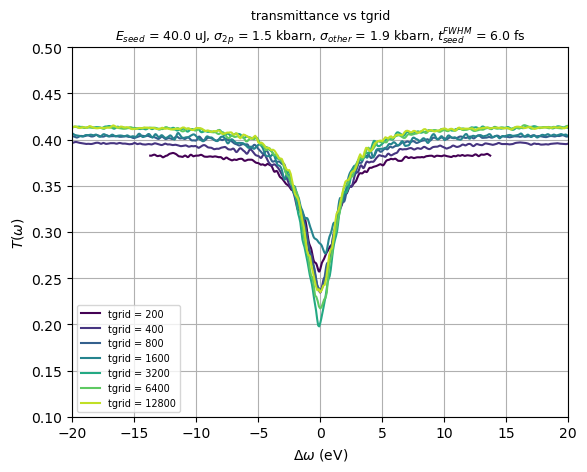

200
400
800
1600
3200
6400
12800
20000


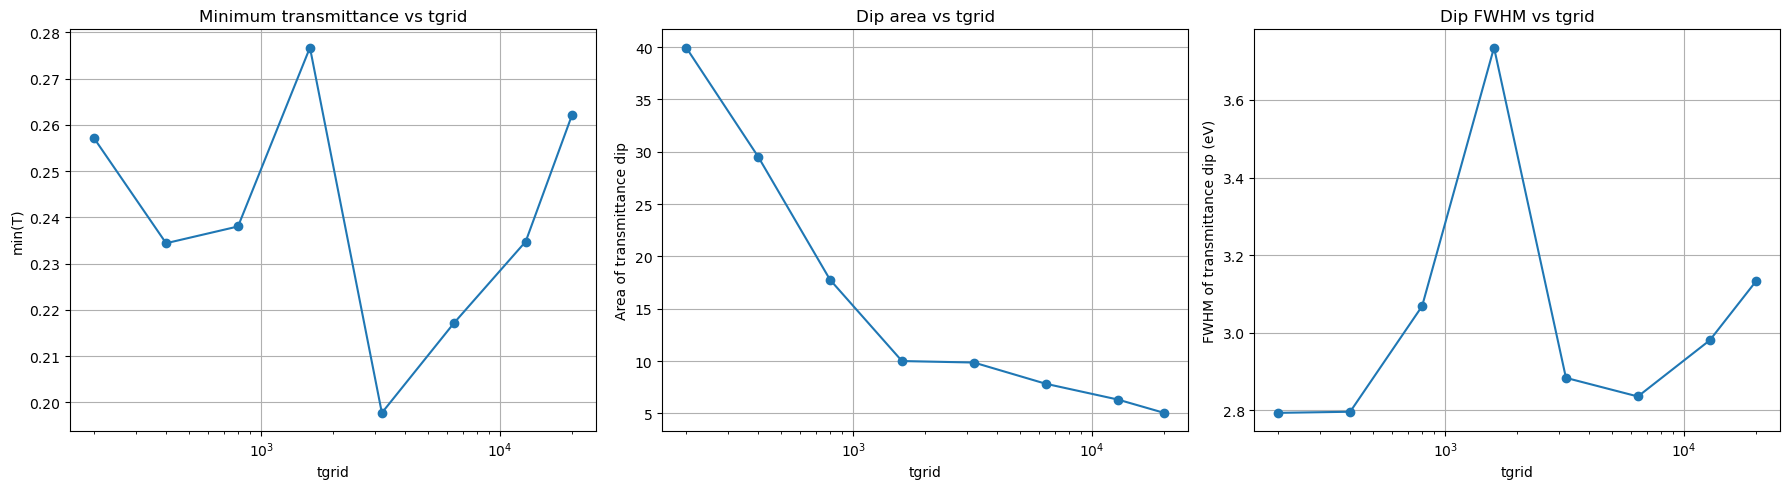

In [31]:
# points at data/convergence_tgrid_<SLURM_ARRAY_JOB_ID> written by scripts/submit_tgrid_sweep.sh --
# update to match the job you ran.
data_path_tgrid = "../data/convergence_tgrid_24007409"

sorted_arrays_tgrid, aux_data_tgrid = data_from_folder(data_path_tgrid, grid_key='tgrid')
_ = plot_transmittance_sweep(sorted_arrays_tgrid, aux_data_tgrid, grid_label='tgrid')


### xgrid/ygrid (transverse grid) convergence

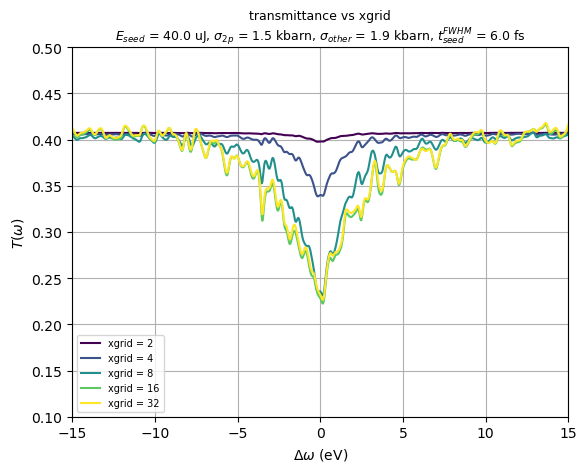

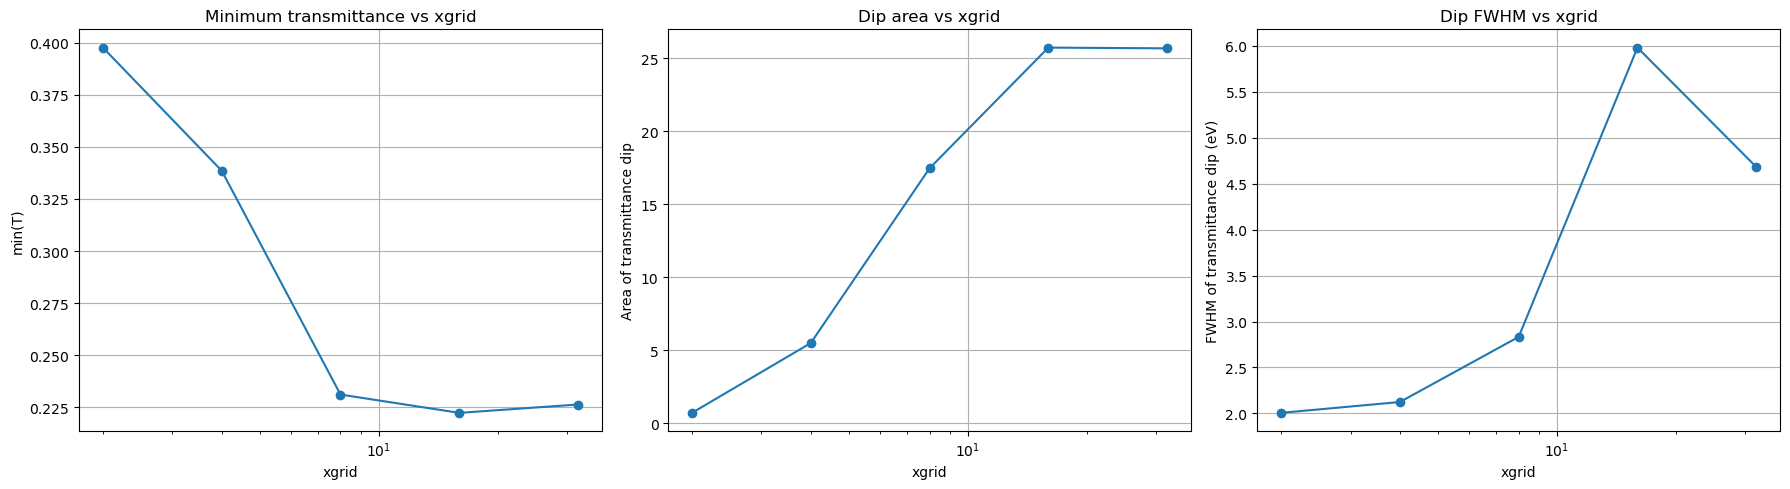

In [9]:
data_path_xygrid = "../data/convergence_xygrid_24005652"

sorted_arrays_xygrid, aux_data_xygrid = data_from_folder(data_path_xygrid, grid_key='xgrid')
_ = plot_transmittance_sweep(sorted_arrays_xygrid, aux_data_xygrid, grid_label='xgrid')


### zgrid convergence

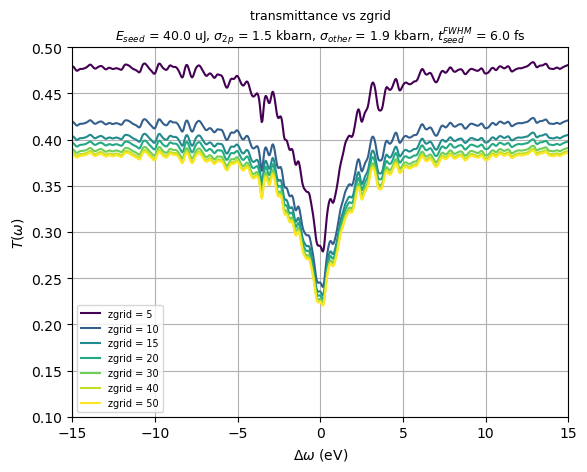

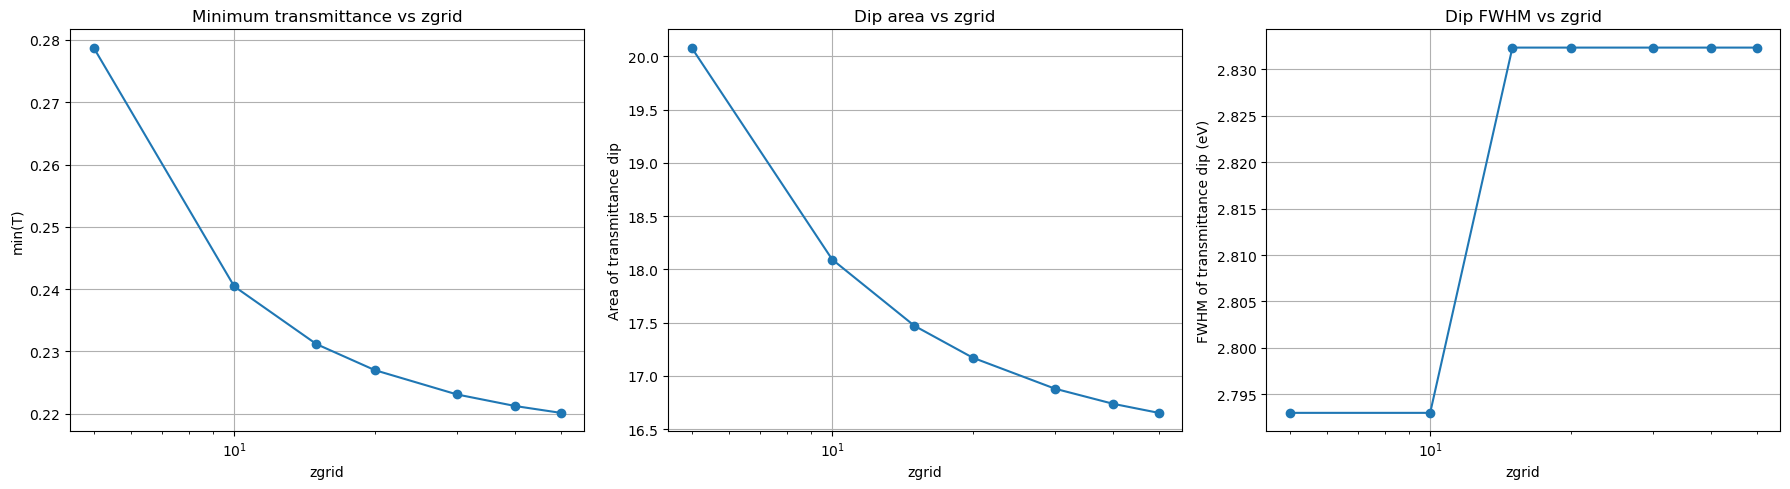

In [10]:
data_path_zgrid = "../data/convergence_zgrid_24005653"

sorted_arrays_zgrid, aux_data_zgrid = data_from_folder(data_path_zgrid, grid_key='zgrid')
_ = plot_transmittance_sweep(sorted_arrays_zgrid, aux_data_zgrid, grid_label='zgrid')
